In [1]:
# 패키지 설치
!pip install "numpy<2.0" "scipy<1.13" ultralytics scikit-learn -U -q

print("✅ 패키지 설치 완료")
!nvidia-smi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 46.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 106.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 30.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6567.6/8062.4 GB disk)


In [3]:
# GitHub 클론
import os

if os.path.exists('MCA'):
    !rm -rf MCA

!git clone https://github.com/ICT-Top-Bottom/MCA.git
%cd MCA
!ls -la

Cloning into 'MCA'...
remote: Enumerating objects: 2362, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 2362 (delta 1), reused 15 (delta 1), pack-reused 2344 (from 2)
Receiving objects: 100% (2362/2362), 2.08 GiB | 57.12 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Updating files: 100% (1734/1734), done.
/kaggle/working/MCA
total 92
drwxr-xr-x 13 root root  4096 Dec  3 14:40 .
drwxr-xr-x  4 root root  4096 Dec  3 14:39 ..
drwxr-xr-x  4 root root  4096 Dec  3 14:40 backupFully
drwxr-xr-x  2 root root  4096 Dec  3 14:40 .claude
drwxr-xr-x  5 root root  4096 Dec  3 14:40 deleteImage
drwxr-xr-x  8 root root  4096 Dec  3 14:40 .git
-rw-r--r--  1 root root   335 Dec  3 14:40 .gitignore
drwxr-xr-x  2 root root 20480 Dec  3 14:40 images
drwxr-xr-x  2 root root 20480 Dec  3 14:40 labels
drwxr-xr-x  3 root root  4096 Dec  3 14:40 MCA
-rw-r--r--  1 root root  1154 Dec  3 14:40 README.md
drwxr-xr-x  2 root root  4096 Dec  

In [4]:
# 데이터 확인
from pathlib import Path
from collections import Counter

images_dir = Path('images')
labels_dir = Path('labels')

total_images = len(list(images_dir.glob('*.jpg')))
print(f"Total Images: {total_images}")

# 클래스 분포
class_ids = []
for label_file in labels_dir.glob('*.txt'):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_ids.append(int(float(parts[0])))

class_distribution = Counter(class_ids)
print(f"\nClass distribution:")
for class_id, count in sorted(class_distribution.items()):
    class_name = ['fully', 'empty', 'combined'][class_id]
    percentage = count / len(class_ids) * 100
    print(f"  {class_name}: {count} ({percentage:.1f}%)")

Total Images: 425

Class distribution:
  fully: 162 (37.4%)
  empty: 122 (28.2%)
  combined: 149 (34.4%)


In [5]:
# Train/Val split
import shutil
from sklearn.model_selection import train_test_split

dataset_dir = Path('dataset')
train_images_dir = dataset_dir / 'images' / 'train'
train_labels_dir = dataset_dir / 'labels' / 'train'
val_images_dir = dataset_dir / 'images' / 'val'
val_labels_dir = dataset_dir / 'labels' / 'val'

if dataset_dir.exists():
    shutil.rmtree(dataset_dir)

train_images_dir.mkdir(parents=True, exist_ok=True)
train_labels_dir.mkdir(parents=True, exist_ok=True)
val_images_dir.mkdir(parents=True, exist_ok=True)
val_labels_dir.mkdir(parents=True, exist_ok=True)

image_files = sorted(images_dir.glob('*.jpg'))
paired_data = []

for img_file in image_files:
    label_file = labels_dir / f"{img_file.stem}.txt"
    if label_file.exists():
        paired_data.append((img_file, label_file))

train_data, val_data = train_test_split(paired_data, test_size=0.2, random_state=42)

print(f"Train: {len(train_data)}, Val: {len(val_data)}")

for img_file, label_file in train_data:
    shutil.copy(img_file, train_images_dir / img_file.name)
    shutil.copy(label_file, train_labels_dir / label_file.name)

for img_file, label_file in val_data:
    shutil.copy(img_file, val_images_dir / img_file.name)
    shutil.copy(label_file, val_labels_dir / label_file.name)

print("Dataset split completed!")

Train: 313, Val: 79
Dataset split completed!


In [6]:
# data.yaml 생성
import yaml

current_dir = os.getcwd()

data_yaml = {
    'path': f'{current_dir}/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'nc': 3,
    'names': ['fully', 'empty', 'combined']
}

with open('data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"Dataset path: {current_dir}/dataset")

Dataset path: /kaggle/working/MCA/dataset


In [9]:
# YOLO11s CCTV Augmented Training
from ultralytics import YOLO

model = YOLO('yolo11s.pt')

results = model.train(
    data='data.yaml',
    epochs=250,  # 120 → 150 (더 긴 학습)
    batch=6,
    imgsz=1024,
    patience=30,  # 25 → 30
    device=0,
    
    # Multi-scale
    multi_scale=True,
    
    # Optimizer: AdamW
    optimizer='AdamW',  # 작은 데이터셋에 좋음
    lr0=0.001,  # 0.01 → 0.001 (낮은 LR)
    lrf=0.01,  # Cosine annealing
    
    # 강화된 증강
    mosaic=1.0,
    mixup=0,  # 조명 변화
    copy_paste=0.0,
    
    # 각도 변화
    degrees=15.0,  # ✅ CCTV 각도
    perspective=0.0005,  # ✅ Perspective transform
    
    # 밝기/대비 강화
    hsv_h=0.02,  # 0.015 → 0.02
    hsv_s=0.8,   # 0.7 → 0.8
    hsv_v=0.5,   # 0.4 → 0.5
    
    # 기본 증강
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.0,
    
    # Warmup
    warmup_epochs=5,
    warmup_momentum=0.8,
    
    project='runs/train',
    name='yolo11s_cctv_augmented',
    exist_ok=True,
    verbose=True,
    save=True,
    save_period=10,
    plots=True,
    val=True,
    amp=True
)

print("\nTraining completed!")

Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=250, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=True, name=yolo11s_cctv_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective=0.0005, plots=True, pose=12.0,

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         79         91      0.916      0.911      0.928      0.694
                 fully         25         26      0.802       0.78      0.803      0.584
                 empty         21         22          1      0.976      0.995       0.84
              combined         33         43      0.946      0.977      0.985      0.658
Speed: 0.5ms preprocess, 10.3ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to /kaggle/working/MCA/runs/train/yolo11s_cctv_augmented

Training completed!



results.png


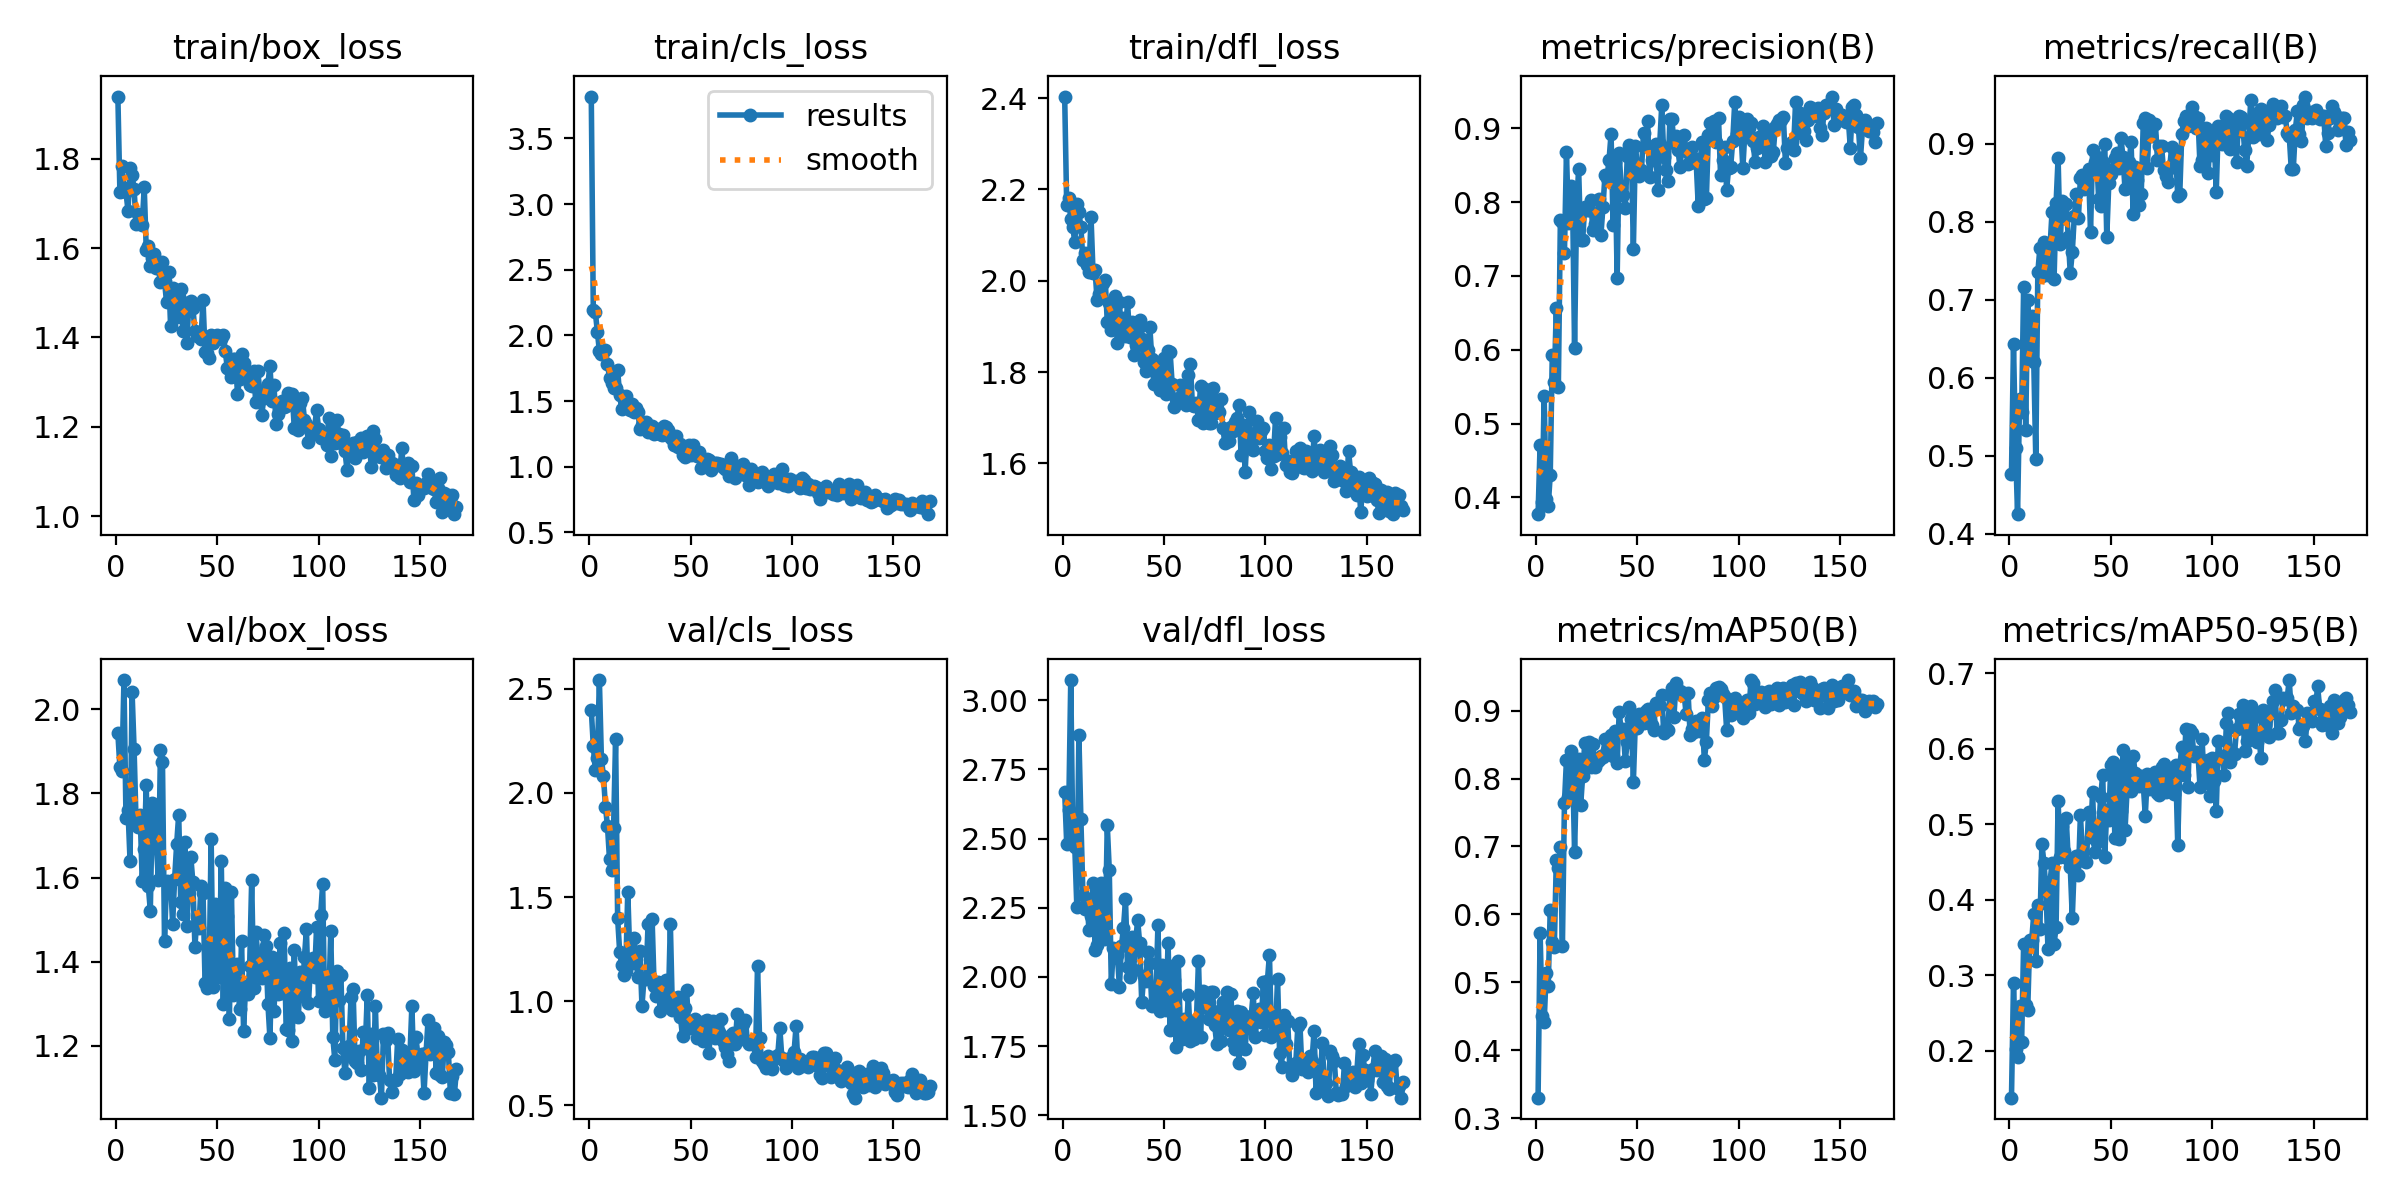


confusion_matrix.png


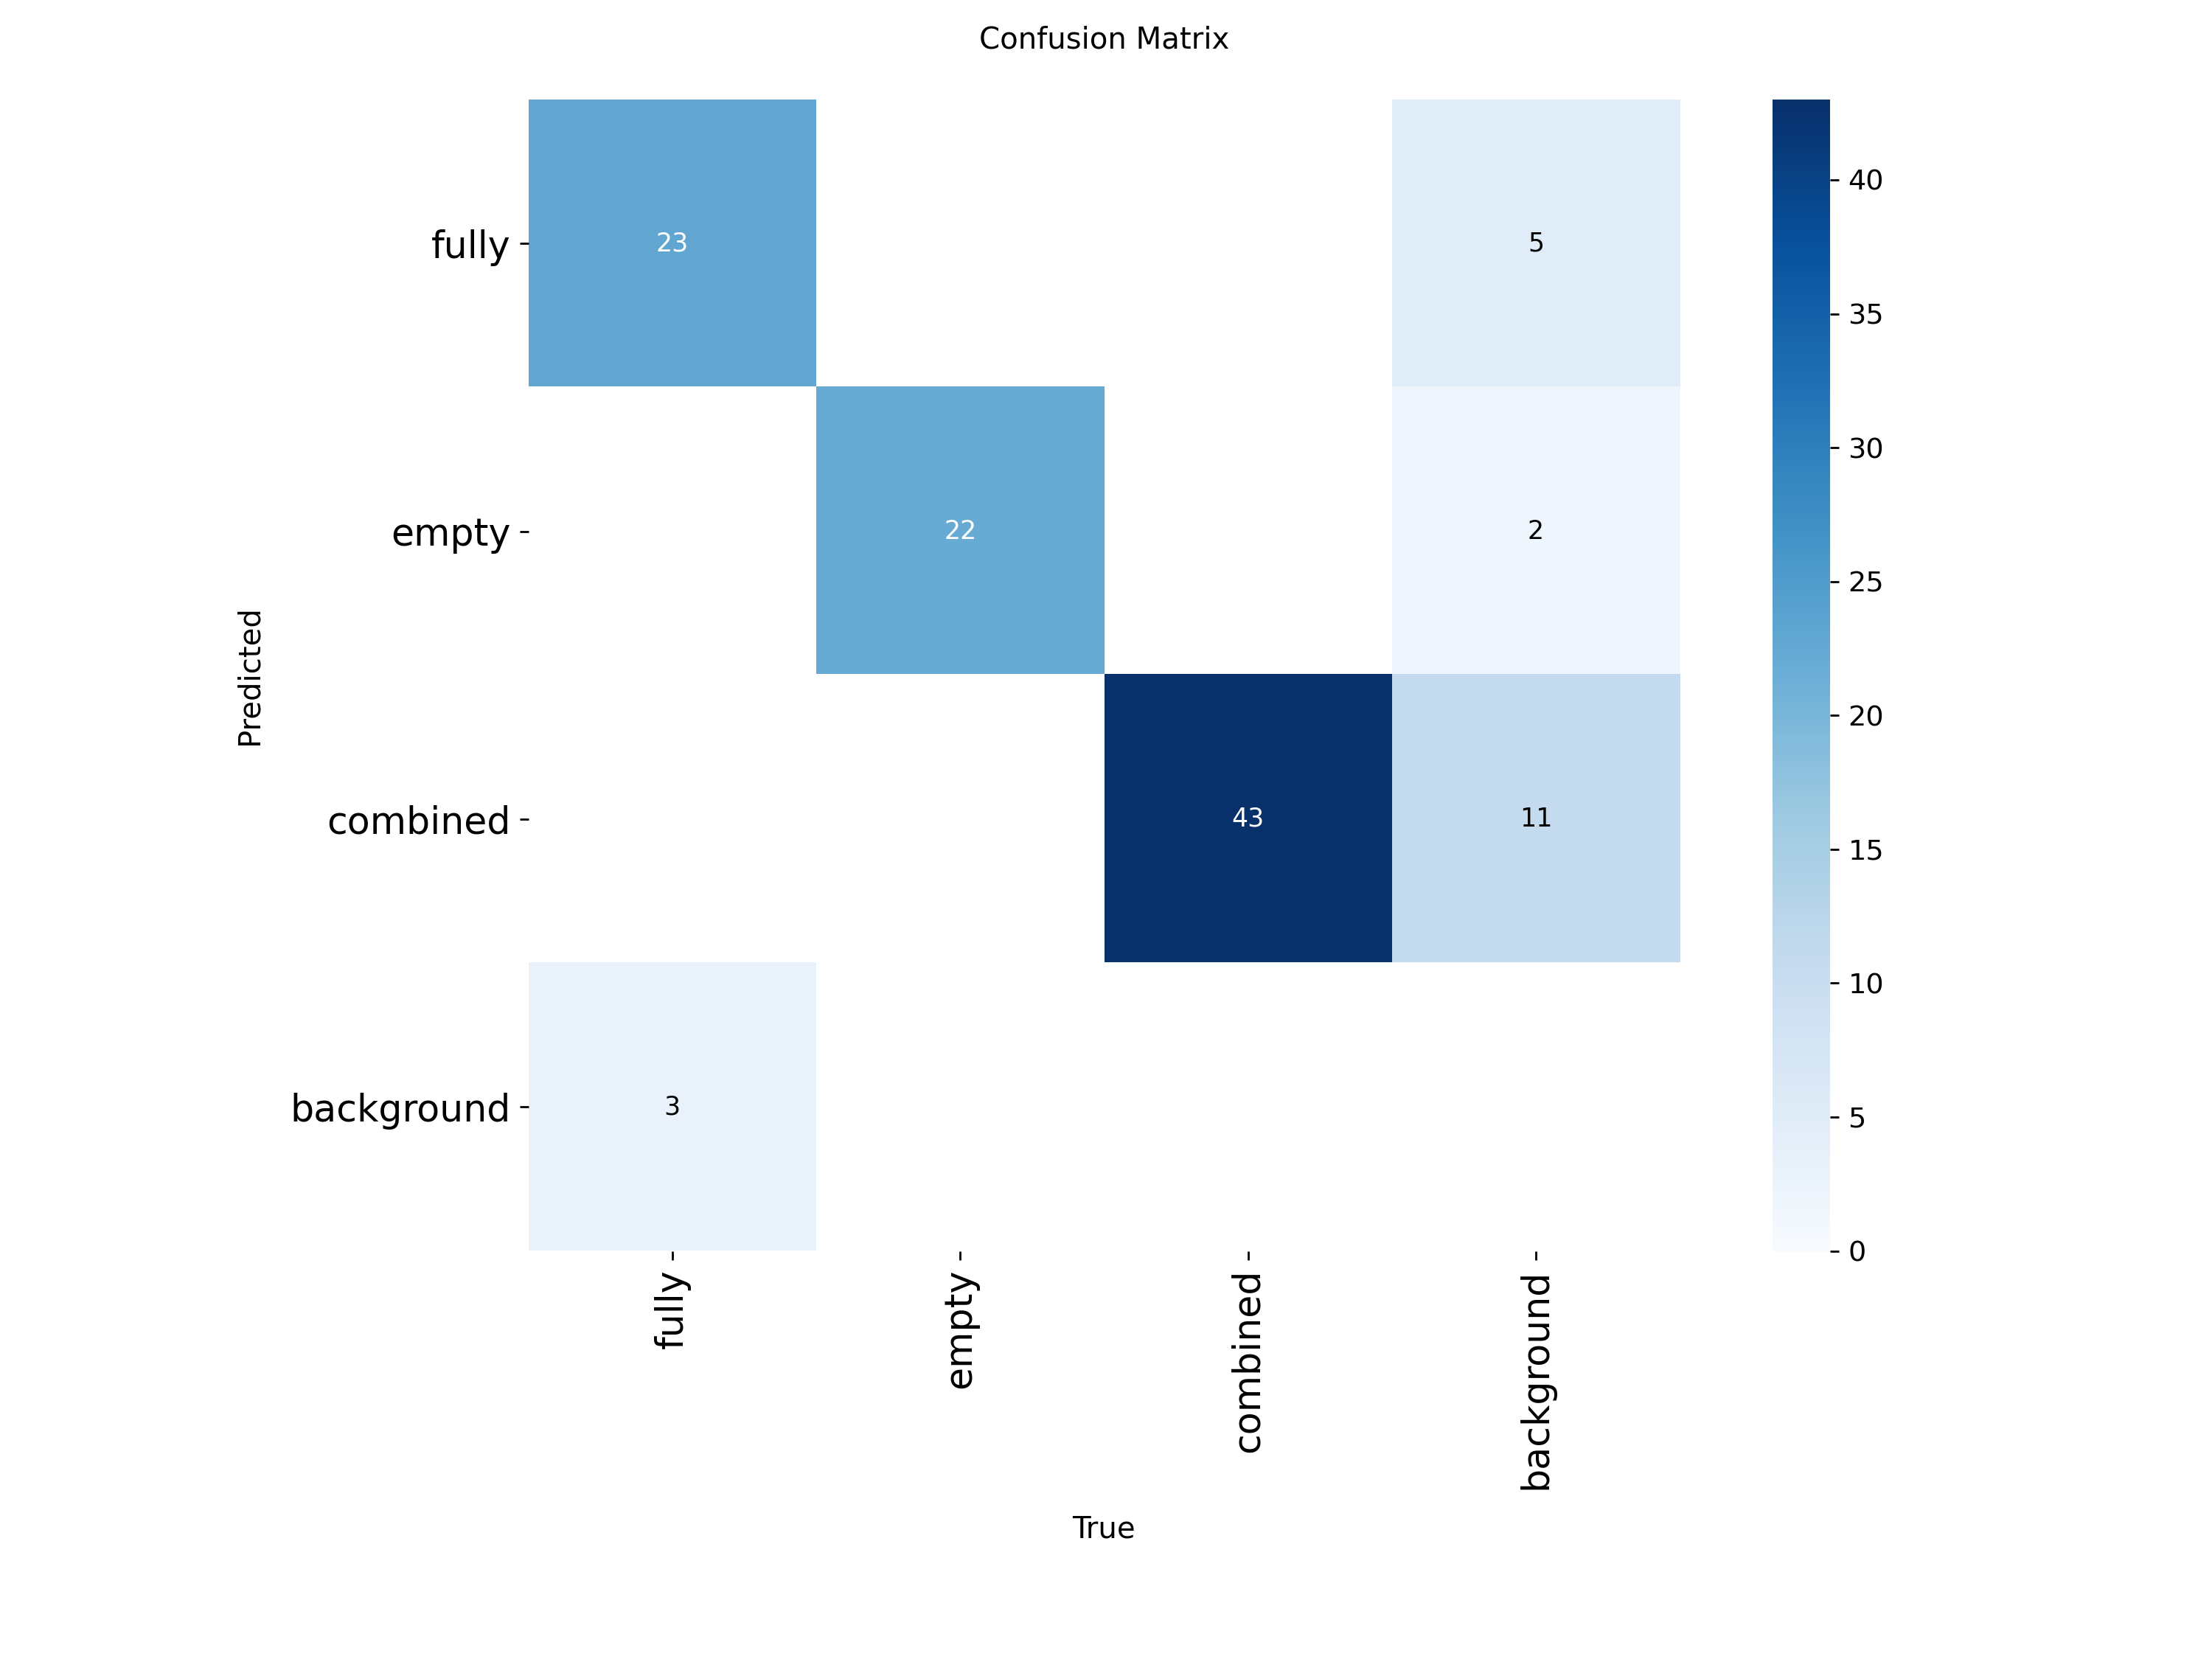


confusion_matrix_normalized.png


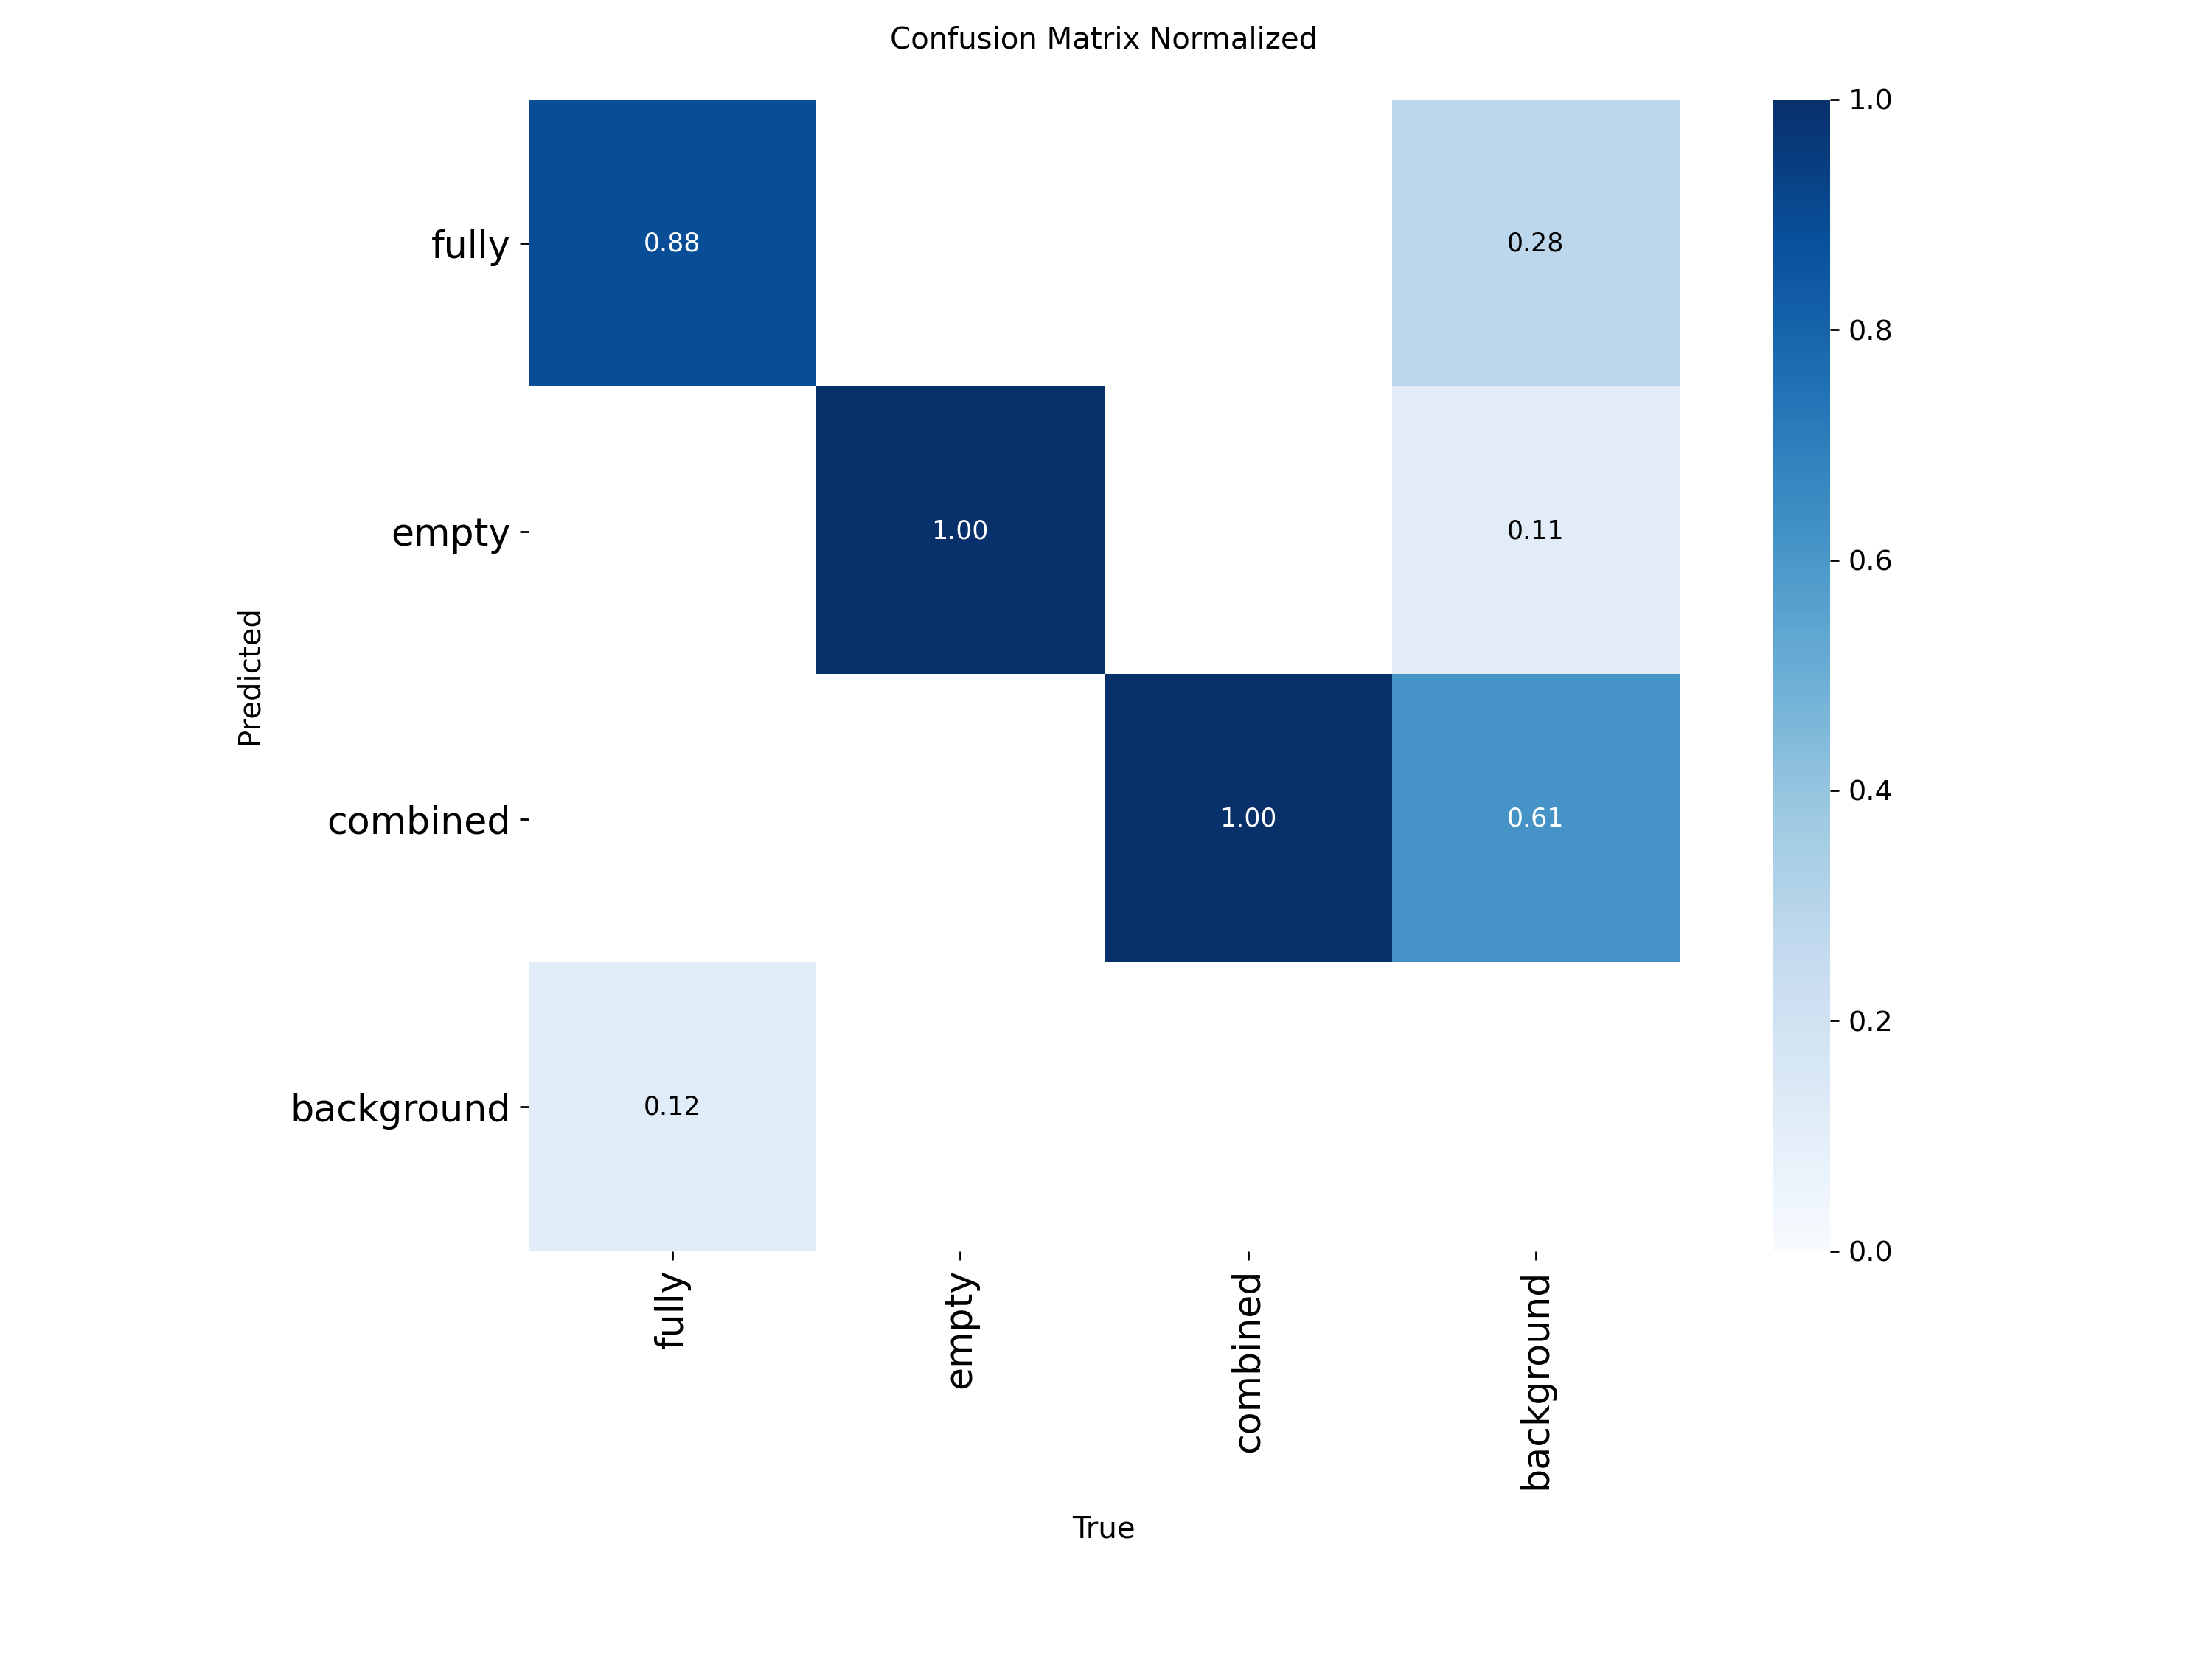

In [14]:
# 결과 시각화
from IPython.display import Image, display

results_dir = 'runs/train/yolo11s_cctv_augmented'

for img_name in ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']:
    img_path = os.path.join(results_dir, img_name)
    if os.path.exists(img_path):
        print(f"\n{'='*60}\n{img_name}\n{'='*60}")
        display(Image(filename=img_path))

In [13]:
# 모델 검증
best_model = YOLO('runs/train/yolo11s_cctv_augmented/weights/best.pt')
metrics = best_model.val(data='data.yaml')

print("\n" + "="*60)
print("Validation Metrics")
print("="*60)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

baseline_map50_95 = 0.8238
improvement = ((metrics.box.map - baseline_map50_95) / baseline_map50_95) * 100

print(f"\nBaseline mAP50-95: {baseline_map50_95:.4f}")
print(f"Current mAP50-95:  {metrics.box.map:.4f}")
print(f"Improvement:       {improvement:+.2f}%")

if metrics.box.map > baseline_map50_95:
    print(f"\n✅ SUCCESS: Improved by {improvement:.2f}%")
else:
    print(f"\n⚠️  Performance: {improvement:+.2f}%")

print("="*60)

Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3863.5±609.7 MB/s, size: 624.5 KB)
val: Scanning /kaggle/working/MCA/dataset/labels/val.cache... 79 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 79/79 157.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0it/s 4.8s1.0ss


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         79         91      0.916      0.911      0.929      0.689
                 fully         25         26      0.802      0.781      0.807      0.587
                 empty         21         22          1      0.976      0.995      0.823
              combined         33         43      0.946      0.977      0.985      0.658
Speed: 9.2ms preprocess, 21.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/MCA/runs/detect/val

Validation Metrics
mAP50:     0.9291
mAP50-95:  0.6892
Precision: 0.9162
Recall:    0.9112

Baseline mAP50-95: 0.8238
Current mAP50-95:  0.6892
Improvement:       -16.34%

⚠️  Performance: -16.34%


In [21]:
# 결과 파일 압축 (다운로드용)
import zipfile

results_output = 'yolo11s_cctv_augmented_results'
train_run_dir = '/kaggle/working/MCA/runs/train/yolo11s_cctv_augmented'

if os.path.exists(results_output):
    shutil.rmtree(results_output)
os.makedirs(results_output)

def safe_copy(src, dst):
    try:
        shutil.copy(src, dst)
        print(f"  ✓ {os.path.basename(src)}")
        return True
    except FileNotFoundError:
        print(f"  ✗ {os.path.basename(src)}")
        return False

print("\n결과 파일 복사...")
safe_copy(f'{train_run_dir}/weights/best.pt', results_output)
safe_copy(f'{train_run_dir}/weights/last.pt', results_output)
safe_copy(f'{train_run_dir}/results.png', results_output)
safe_copy(f'{train_run_dir}/results.csv', results_output)
safe_copy(f'{train_run_dir}/confusion_matrix.png', results_output)
safe_copy(f'{train_run_dir}/confusion_matrix_normalized.png', results_output)
safe_copy('/kaggle/working/MCA/data.yaml', results_output)

# Performance report
report = {
    "model": "YOLO11s CCTV Augmented",
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "metrics": {
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr)
    }
}

with open(f'{results_output}/performance_report.json', 'w') as f:
    json.dump(report, f, indent=2)

# ZIP 압축
print("\n결과 파일 압축 중...")
zip_path = 'yolo11s_cctv_augmented.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(results_output):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.join('yolo11s_cctv_augmented', os.path.relpath(file_path, results_output))
            zipf.write(file_path, arcname)
            print(f"  ✓ {arcname}")

print(f"\n✅ 압축 완료: {zip_path}")
print("Kaggle 우측 상단 Output에서 이 파일을 다운로드하세요!")


결과 파일 복사...
  ✓ best.pt
  ✓ last.pt
  ✓ results.png
  ✓ results.csv
  ✓ confusion_matrix.png
  ✓ confusion_matrix_normalized.png
  ✓ data.yaml


OSError: [Errno 28] No space left on device